In [1]:
import os
import tifffile
import math
import numpy as np
from typing import Optional
import scipy.io as sio
import rasterio

import torch
import torch.nn as nn
import torch.nn.functional as F
#from pytorch_msssim import ssim
from torchvision.models import resnet101
from torch.utils.data import Dataset, DataLoader
from torchvision.models.feature_extraction import create_feature_extractor
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler

#from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.manual_seed(42)
print(f"Using device: {device}")

Using device: cuda


In [3]:
patches_folder='dc'
file_prefix='dc_290'

initialization_path = 'Data/Input/dc_vca.pt'

num_endmembers = 6

In [4]:
data = torch.load(initialization_path)

vca_spectra   = data['vca_spectra'].cuda()  # move to GPU if you like
gt_spectra    = data['gt_spectra'].cuda()
# vca_spectra   = vca_spectra.permute(0,2,1)
# gt_spectra    = gt_spectra.permute(0,2,1)
print("Loaded data")
print("VCA spectra shape:", vca_spectra.shape)
print("GT spectra shape: ", gt_spectra.shape)

Loaded data
VCA spectra shape: torch.Size([1, 6, 191])
GT spectra shape:  torch.Size([1, 6, 191])


In [5]:
def spectral_angle_loss(recon, target):
    # both [B, F, H, W] → flatten to [B, F, Npix]
    a = recon.view(recon.size(0), recon.size(1), -1)
    b = target.view(target.size(0), target.size(1), -1)
    # cosine similarity
    cs = (a * b).sum(dim=1) / (a.norm(dim=1) * b.norm(dim=1) + 1e-6)
    # angle in radians
    sam = torch.acos(cs.clamp(-1+1e-6, 1-1e-6))
    return sam.mean()

In [6]:
class HSIPatchDataset(Dataset):
    def __init__(self, patches_folder, file_prefix, num_endmembers,
                 vca_tensor, gt_tensor, transform=None):
        """
        Dataset for loading preprocessed and normalized HSI patches with
        matching VCA/GT spectra from a multi-band TIFF.

        Parameters:
            patches_folder (str): Directory where the patch TIFF files are stored.
            file_prefix (str): Filename prefix for the patch file (e.g., "tile761_patch46").
            num_endmembers (int): Number of endmembers for this patch.
            vca_tensor (torch.Tensor): [N, E, bands] per-patch VCA spectra.
            gt_tensor  (torch.Tensor): [N, E, bands] per-patch GT spectra.
            transform (callable, optional): Optional transform to be applied on a patch.
        """
        self.patches_folder = patches_folder
        self.file_prefix = file_prefix
        self.num_endmembers = num_endmembers
        self.patch_number = 46   # still hard-coded here; adjust if needed
        self.length = 1          # dataset of size 1; adjust if you have more patches
        self.vca = vca_tensor.float()
        self.gt = gt_tensor.float()
        self.transform = transform

    def __len__(self):
        return self.length
        
    def __getitem__(self, idx):
        num_endmembers = self.num_endmembers
        patch_number = self.patch_number

        # Build file path and read multi-band TIFF
        filename = f"{self.file_prefix}.tif"
        file_path = os.path.join(self.patches_folder, filename)
        with rasterio.open(file_path) as src:  # <-- no driver='ENVI'
            patch = src.read()   # shape: (bands, H, W)

        # Convert to float32 Tensor
        patch_tensor = torch.from_numpy(patch.astype('float32'))  # [bands, H, W]
        
        # L2-normalize each pixel's spectrum (across bands)
        flat = patch_tensor.view(patch_tensor.size(0), -1)        # [bands, H*W]
        flat = F.normalize(flat, p=2, dim=0, eps=1e-6)
        patch_tensor = flat.view_as(patch_tensor)                 # back to [bands, H, W]
        
        # Optional transform (e.g., augmentations)
        if self.transform:
            patch_tensor = self.transform(patch_tensor)

        # Select and L2-normalize VCA and GT spectra
        vca_spec = F.normalize(self.vca[idx], p=2, dim=-1, eps=1e-6)  # [E, bands]
        gt_spec  = F.normalize(self.gt[idx],  p=2, dim=-1, eps=1e-6)  # [E, bands]

        return {
            "patch": patch_tensor,              # Tensor: [bands, H, W]
            "vca":   vca_spec,                  # [E, bands]
            "gt":    gt_spec,                   # [E, bands]
            "patch_number": patch_number,       # int
            "num_endmembers": num_endmembers    # int
        }

In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):
        # x: [B, tokens, embed_dim]
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class HSITransformer(nn.Module):
    def __init__(self,
                 bands,
                 embed_dim,
                 num_heads,
                 mlp_dim,
                 num_layers,
                 num_endmembers,
                 patch_size=2):
        super().__init__()
        self.patch_size   = patch_size
        # number of patches per side = 256/patch_size
        num_patches_side = 290 // patch_size
        self.num_patches = num_patches_side ** 2

        # 1) Patch embedding: conv with kernel=stride=patch_size
        self.patch_embed = nn.Conv2d(
            in_channels=bands,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # 2) Special tokens: [CLS], VCA-init, GT-init
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # total tokens = 1 cls + 1 vca + 1 gt + patch tokens
        total_tokens = 1 + 1 + 1 + self.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, total_tokens, embed_dim))

        # 3) Embed your initializations via 1D conv over the band dimension
        #    Input shape: (B, E, bands) → transpose to (B, bands, E)
        #    Conv1d(in=bands, out=embed_dim, kernel=1) produces (B, embed_dim, E)
        #    We then average over E to get one vector per sample
        self.vca_conv = nn.Conv1d(in_channels=bands,
                                   out_channels=embed_dim,
                                   kernel_size=1)
        self.gt_conv  = nn.Conv1d(in_channels=bands,
                                   out_channels=embed_dim,
                                   kernel_size=1)

        # 4) Transformer encoder stack
        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim)
            for _ in range(num_layers)
        ])

        # 5) Head: map back to abundance per patch, then upsample
        self.head = nn.Conv2d(embed_dim, num_endmembers, kernel_size=1)

        # 6) Fold layer for reconstruction
        self.fold = nn.Fold(
            output_size=(290, 290),
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x, vca_init, gt_init, return_full=False):
        """
        x        : (B, bands, 256, 256)
        vca_init : (B, E, bands)
        gt_init  : (B, E, bands)
        """
        B = x.size(0)

        # ——— Patchify + embed —————————————————————————
        # (B, bands, 256,256) → Conv2d → (B, embed_dim, 16,16)
        patches = self.patch_embed(x)
        # flatten spatial to sequence:
        # → (B, embed_dim, num_patches) → transpose → (B, num_patches, embed_dim)
        tokens_local = patches.flatten(2).transpose(1, 2)

        # ——— Embed VCA initialization —————————————————————
        # (B, E, bands) → permute → (B, bands, E) → Conv1d → (B,embed_dim,E)
        vca_emb = self.vca_conv(vca_init.permute(0, 2, 1))
        #vca_emb = self.vca_conv(vca_init)
        # average over endmember dimension → (B, embed_dim)
        vca_tok = vca_emb.mean(dim=2, keepdim=True).transpose(1, 2)

        # ——— Embed GT initialization ——————————————————————
        gt_emb  = self.gt_conv(gt_init.permute(0, 2, 1))
        #gt_emb  = self.gt_conv(gt_init)
        gt_tok  = gt_emb.mean(dim=2, keepdim=True).transpose(1, 2)

        # ——— Prepare CLS token ————————————————————————
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B,1,embed_dim)

        # ——— Concatenate all tokens —————————————————————
        # order: [CLS] [VCA] [GT] [patch tokens...]
        tokens = torch.cat([cls_tokens, vca_tok, gt_tok, tokens_local], dim=1)

        # ——— Add positional embeddings ————————————————————
        tokens = tokens + self.pos_embed

        # ——— Transformer encoding ——————————————————————
        encoded = self.encoder(tokens)  # (B, total_tokens, embed_dim)

        # ——— Remove special tokens and reshape to 2D grid ————
        # drop first 3 tokens: → (B, num_patches, embed_dim)
        patch_tokens = encoded[:, 3:, :]
        # back to (B, embed_dim, 16,16)
        Hp = Wp = 290 // self.patch_size
        feat = patch_tokens.transpose(1, 2).view(B, self.patch_embed.out_channels, Hp, Wp)

        # ——— Abundance heads + upsample ——————————————————
        # predict per‐patch abundances: (B, num_endmembers, 16, 16)
        ab_patch = self.head(feat)

        ab_patch   = F.softmax(ab_patch, dim=1)


        if return_full:
            ab_map = self._reconstruct_with_fold(ab_patch)
            return ab_map
        else:
            return ab_patch
            
        # # ─── Reconstruct full 256×256 by tiling each patch ───────────────────
        # # Repeat each patch value patch_size times in H and W:
        # ab_map = ab_patch.repeat_interleave(self.patch_size, dim=2) \
        #                     .repeat_interleave(self.patch_size, dim=3)
        # # Now full_map: (B, num_endmembers, P*patch_size, P*patch_size)
        # # i.e. (B, num_endmembers, 256, 256)

    def _reconstruct_with_fold(self, ab_patch):
            B, C, P_h, P_w = ab_patch.shape
            num_patches    = P_h * P_w
            patch_area     = self.patch_size * self.patch_size
    
            # Flatten to (B, C, L)
            patches = ab_patch.view(B, C, num_patches)
    
            # Expand each patch element into patch_area
            patches = patches.unsqueeze(-1).expand(-1, -1, -1, patch_area)
            patches = patches.reshape(B, C * patch_area, num_patches)
    
            # Fold back to (B, C, 256, 256)
            full_map = self.fold(patches)
            return full_map

In [8]:
# 0) Early stopping params
patience           = 100              # quante epoche di plateau prima di fermarsi
best_loss          = float('inf')     # inizialmente infinito
epochs_without_improvement = 0

# 1) Hyperparameters
lr          = 1e-3
num_epochs  = 1000
batch_size  = 1

# 2) Model, optimizer, loss
model       = HSITransformer(
    bands=191, embed_dim=64,
    num_heads=2, mlp_dim=128, num_layers=4,
    num_endmembers=num_endmembers,
    patch_size=2
)
pos_init = model.pos_embed.detach().cpu().clone().numpy()[0] 
# 2) If you have more than 1 GPU, wrap in DataParallel
if torch.cuda.device_count() > 1:
    print(f"Detected {torch.cuda.device_count()} GPUs. Using DataParallel.")
    model = nn.DataParallel(model, device_ids=[0,1,2])

model = model.to(device)

optimizer   = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
               mode='min', factor=0.1, patience=50, min_lr=1e-5)
criterion   = nn.MSELoss()


# right after you load/model-init your vca/gt
vca_spectra_cpu = vca_spectra.detach().cpu()
gt_spectra_cpu = gt_spectra.detach().cpu()

# 3) DataLoader (reuse your HSIPatchDataset)
dataset     = HSIPatchDataset(
    patches_folder=patches_folder,
    file_prefix=file_prefix,
    num_endmembers=6,
    vca_tensor=vca_spectra_cpu,    # [N, E, bands]
    gt_tensor=gt_spectra_cpu       # [N, E, bands]
)
dataloader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

In [9]:
# 4) Training loop
loss_history = []

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0

    for batch in dataloader:
        x      = batch['patch'].to(device, non_blocking=True)   # [B, bands, H, W]
        vca    = batch['vca'].to(device, non_blocking=True)     # [B, E, bands]
        gt     = batch['gt'].to(device, non_blocking=True)      # [B, E, bands]

        optimizer.zero_grad()

        # forward pass → abundance maps [B, E, H, W]
        abundances = model(x, vca, gt, return_full=True)

        # reconstruct the patch: R[b,f,i,j] = sum_e abundances[b,e,i,j] * vca[b,e,f]
        # Using einsum for clarity:
        reconstruction = torch.einsum('behw,bef->bfhw', abundances, vca)
        
        # # 1) Upsample a 256×256
        # reconstruction= F.interpolate(
        #     reconstruction,
        #     size=(x.shape[2], x.shape[3]),    # (256,256)
        #     mode='bilinear',
        #     align_corners=False
        # )
        
        # compute MSE loss between original and reconstruction
        # in training:
        loss_mse = criterion(reconstruction, x)
        loss_sam = spectral_angle_loss(reconstruction, x)
        loss = loss_mse + 0.1 * loss_sam
        #loss = criterion(reconstruction, x)

        loss.backward()
        
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch}/{num_epochs} — Loss: {epoch_loss:.6f}")
    scheduler.step(epoch_loss)

    # --- Early stopping check ---
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        epochs_without_improvement = 0
        # (opzionale) salva il modello migliore
        #torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_without_improvement += 1
        print(f"  ↳ nessun miglioramento per {epochs_without_improvement}/{patience} epoche")

    if epochs_without_improvement >= patience:
        print(f"Early stopping dopo {epoch} epoche (pazienza esaurita).")
        break

print("Training complete.")

Epoch 1/1000 — Loss: 0.036521
Epoch 2/1000 — Loss: 0.036214
Epoch 3/1000 — Loss: 0.033160
Epoch 4/1000 — Loss: 0.035238
  ↳ nessun miglioramento per 1/100 epoche
Epoch 5/1000 — Loss: 0.033475
  ↳ nessun miglioramento per 2/100 epoche
Epoch 6/1000 — Loss: 0.032270
Epoch 7/1000 — Loss: 0.031088
Epoch 8/1000 — Loss: 0.031233
  ↳ nessun miglioramento per 1/100 epoche
Epoch 9/1000 — Loss: 0.031676
  ↳ nessun miglioramento per 2/100 epoche
Epoch 10/1000 — Loss: 0.031424
  ↳ nessun miglioramento per 3/100 epoche
Epoch 11/1000 — Loss: 0.031945
  ↳ nessun miglioramento per 4/100 epoche
Epoch 12/1000 — Loss: 0.031332
  ↳ nessun miglioramento per 5/100 epoche
Epoch 13/1000 — Loss: 0.030819
Epoch 14/1000 — Loss: 0.030985
  ↳ nessun miglioramento per 1/100 epoche
Epoch 15/1000 — Loss: 0.031222
  ↳ nessun miglioramento per 2/100 epoche
Epoch 16/1000 — Loss: 0.031118
  ↳ nessun miglioramento per 3/100 epoche
Epoch 17/1000 — Loss: 0.030770
Epoch 18/1000 — Loss: 0.030758
Epoch 19/1000 — Loss: 0.030867


In [10]:
# %%
import time
import numpy as np
import torch

model.eval()

# take one representative batch
batch = next(iter(dataloader))
x   = batch["patch"].to(device, non_blocking=True)
vca = batch["vca"].to(device, non_blocking=True)
gt  = batch["gt"].to(device, non_blocking=True)

# optional: if using DataParallel, underlying model is still fine through model(...)
# no change needed

# -----------------------------
# 1) Warm-up
# -----------------------------
with torch.no_grad():
    for _ in range(20):
        _ = model(x, vca, gt)

torch.cuda.synchronize()

# -----------------------------
# 2) Measure inference latency
# -----------------------------
n_runs = 100
latencies = []

torch.cuda.reset_peak_memory_stats(device)

with torch.no_grad():
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = model(x, vca, gt)
        torch.cuda.synchronize()
        end = time.perf_counter()
        latencies.append(end - start)

avg_latency_s = float(np.mean(latencies))
std_latency_s = float(np.std(latencies))
fps = 1.0 / avg_latency_s
peak_inference_mem_gb = torch.cuda.max_memory_allocated(device) / (1024**3)

print(f"Average inference latency: {avg_latency_s*1000:.3f} ms/image")
print(f"Latency std: {std_latency_s*1000:.3f} ms")
print(f"FPS: {fps:.3f}")
print(f"Peak inference memory: {peak_inference_mem_gb:.3f} GB")

Average inference latency: 122.754 ms/image
Latency std: 0.114 ms
FPS: 8.146
Peak inference memory: 6.867 GB


In [28]:
def visualize_abundances_with_patch(abundances, patches, patch_ids=None, band=12, figsize_per=3):
    """
    Visualizza un batch di abundance maps disposte in due righe:
      - riga 0: il patch nella banda specificata (nel primo subplot)
      - riga 1: le E abundance maps (una per endmember)

    Parameters:
        abundances (torch.Tensor): [B, E, H, W] output del modello.
        patches    (torch.Tensor): [B, bands, H, W] input originale.
        patch_ids  (list[int], optional): identificativi delle patch.
        band       (int): indice della banda da mostrare, default 12.
        figsize_per(float): dimensione di ciascun subplot in pollici.
    """
    import matplotlib.pyplot as plt

    abund_np = abundances.detach().cpu().numpy()
    patch_np  = patches.detach().cpu().numpy()
    B, E, H, W = abund_np.shape

    for i in range(B):
        fig, axes = plt.subplots(2, E, 
                                 figsize=(figsize_per * E, figsize_per * 2),
                                 squeeze=False)
        # --- prima riga: patch (band 'band') in axes[0,0], gli altri a vuoto
        ax0 = axes[0, 0]
        im0 = ax0.imshow(patch_np[i, band], cmap='gray')
        title = f'Patch {patch_ids[i]}' if patch_ids else f'Sample {i}'
        ax0.set_title(f'{title}\nBand {band}')
        ax0.axis('off')
        fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        # nascondi eventuali subplot vuoti in prima riga
        for j in range(1, E):
            axes[0, j].axis('off')

        # --- seconda riga: le E abundance maps
        for e in range(E):
            ax = axes[1, e]
            im = ax.imshow(abund_np[i, e], cmap='jet', vmin=0, vmax=1)
            ax.set_title(f'EM {e}')
            ax.axis('off')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

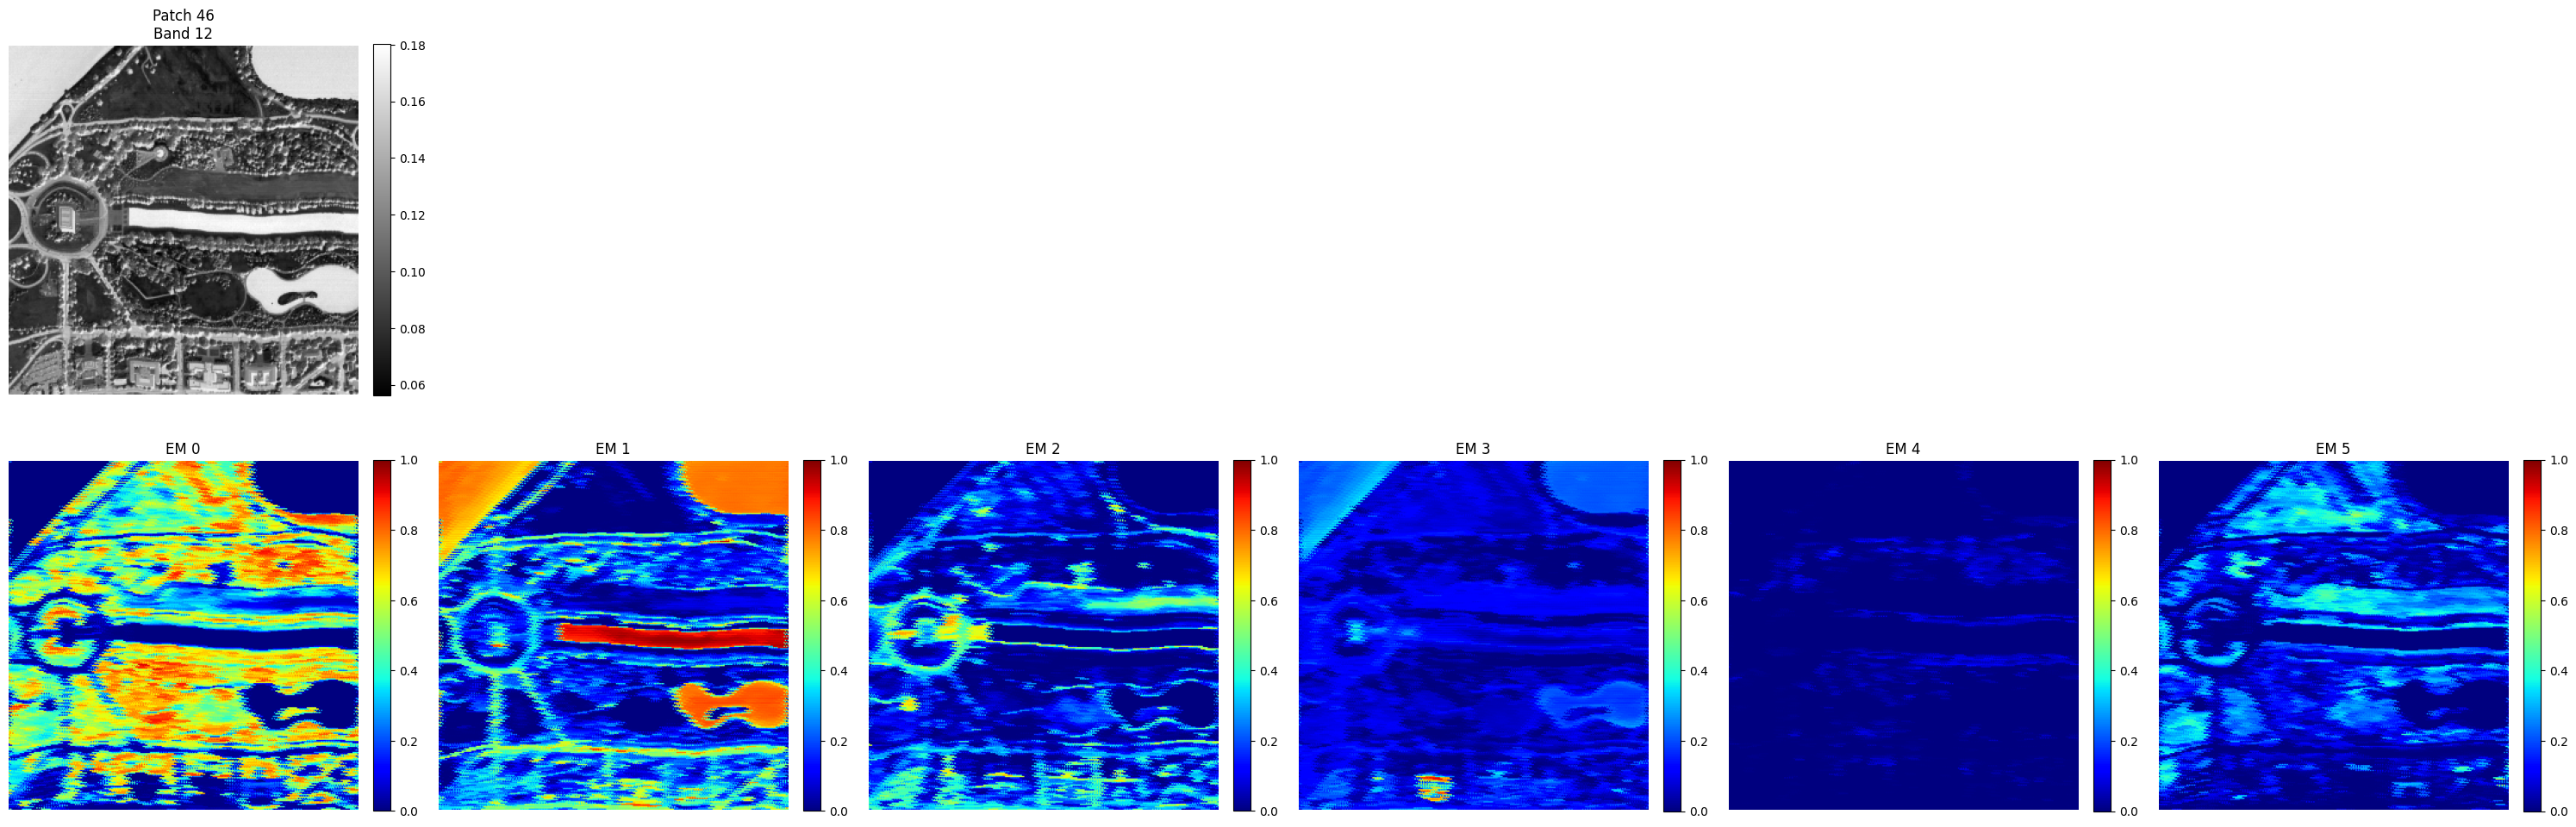

In [29]:
# prendi un batch
batch = next(iter(dataloader))
x          = batch['patch']        # [B, bands, H, W]
abundances = model(x.cuda(), batch['vca'].cuda(), batch['gt'].cuda(), return_full=True)
patch_ids  = batch['patch_number'] # lista di interi

visualize_abundances_with_patch(
    abundances,
    x,
    patch_ids=patch_ids,
    band=12,
    figsize_per=5
)

In [30]:
ab_np = abundances[0].detach().cpu().numpy()   # → (E, H, W)
ab_np.shape
np.save('ViT_dc_abundances.npy', ab_np)

/tmp/ipykernel_735830/3372663776.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
/tmp/ipykernel_735830/3372663776.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
/tmp/ipykernel_735830/3372663776.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
/tmp/ipykernel_735830/3372663776.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement

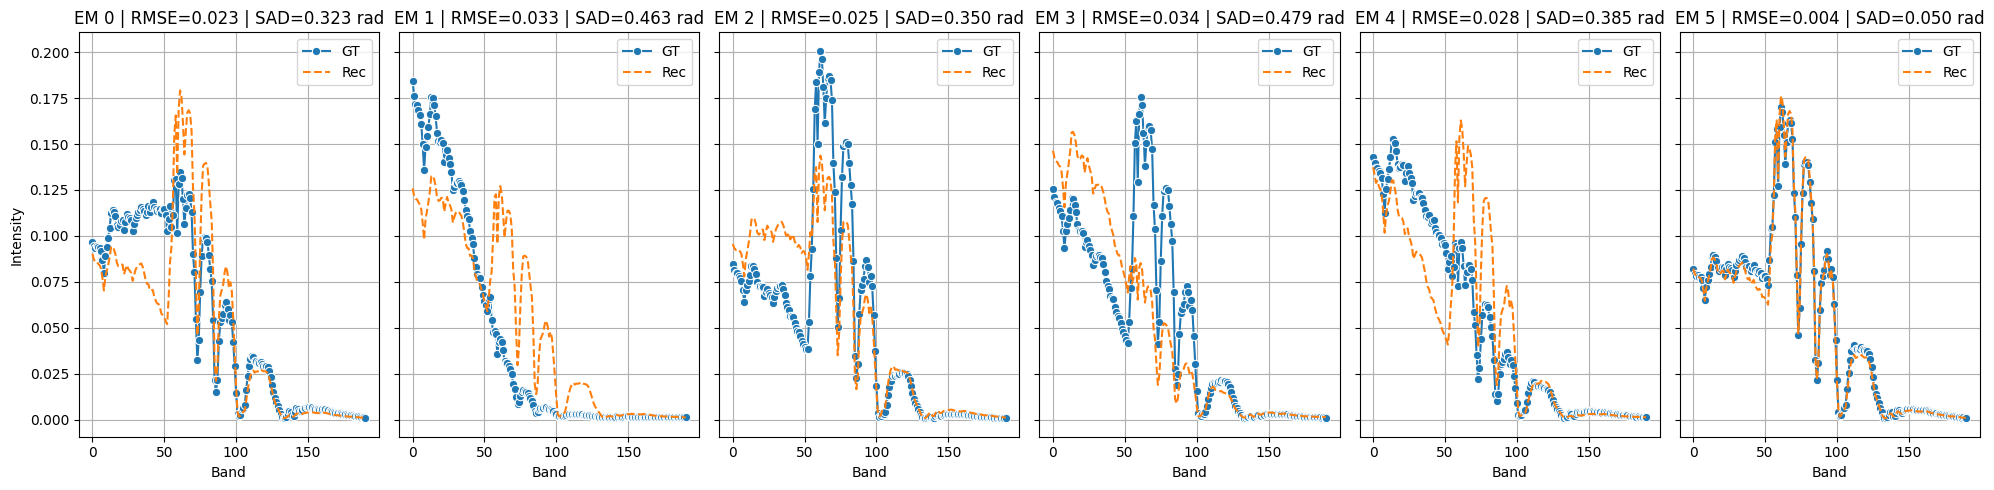

In [31]:
from sklearn.metrics import mean_squared_error

def spectral_angle(a, b):
    """SAD in radians between two 1D NumPy arrays."""
    cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
    cos = np.clip(cos, -1, 1)
    return np.arccos(cos)

def weighted_median(data, weights):
    """
    Compute the weighted median of 1D `data` with positive `weights`.
    """
    # sort data and weights by data value
    idx = np.argsort(data)
    d = data[idx]
    w = weights[idx]
    cum = np.cumsum(w)
    cutoff = w.sum() / 2.0
    return d[np.searchsorted(cum, cutoff)]

# 1) Fetch one patch, its abundances, and the GT spectra
batch  = next(iter(dataloader))
x_t    = batch['patch'][0].cpu()       # [bands, H, W]
abund_t= (model(batch['patch'].cuda(),
                batch['vca'].cuda(),
                batch['gt'].cuda(),return_full=True)
           .detach()
           .cpu()[0])                   # [E, h', w']
spec_gt= batch['gt'][0].cpu()          # [E, bands]

# 2) Convert to NumPy and check shapes
fm1 = abundances.detach().cpu()[0]
x_np     = x_t.numpy()                 # [bands, H, W]
abund_np = fm1.numpy()             # [E, h', w']
gt_np    = spec_gt.numpy()             # [E, bands]

bands, H, W = x_np.shape
E,  h2, w2  = abund_np.shape

lower_thresh = 0.12
upper_thresh =1
E =6
rec_specs = []
for e in range(E):
    a = fm1[e]   # [h', w'] abundance map for endmember e
    # keep only pixels with lower_thresh < a < upper_thresh
    mask = (a > lower_thresh) & (a < upper_thresh)  

    if mask.sum() == 0:
        rec_specs.append(torch.zeros(bands, device=x_t.device))
        continue

    selected = x_t[:, mask]           # [bands, N_pixels]
    med = selected.median(dim=1).values  # [bands]
    rec_specs.append(med)

rec_specs = torch.stack(rec_specs)      # [E, bands]
# perm = [3, 1, 2, 0]
# rec_specs = rec_specs[perm]
# 5) Plot GT vs. Rec with RMSE & SAD
cols      = 6
rows      = int(np.ceil(E / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 5), sharex=True, sharey=True)
axes      = axes.flatten()
x_axis    = np.arange(bands)

for i in range(E):
    ax   = axes[i]
    sns.lineplot(x=x_axis, y=gt_np[i],  ax=ax, label='GT', marker='o')
    sns.lineplot(x=x_axis, y=rec_specs[i], ax=ax, label='Rec', linestyle='--')
    rmse = np.sqrt(mean_squared_error(gt_np[i], rec_specs[i]))
    sad  = spectral_angle(gt_np[i], rec_specs[i])
    ax.set_title(f'EM {i} | RMSE={rmse:.3f} | SAD={sad:.3f} rad')
    ax.set_xlabel('Band')
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(True)

# remove unused axes
for j in range(E, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


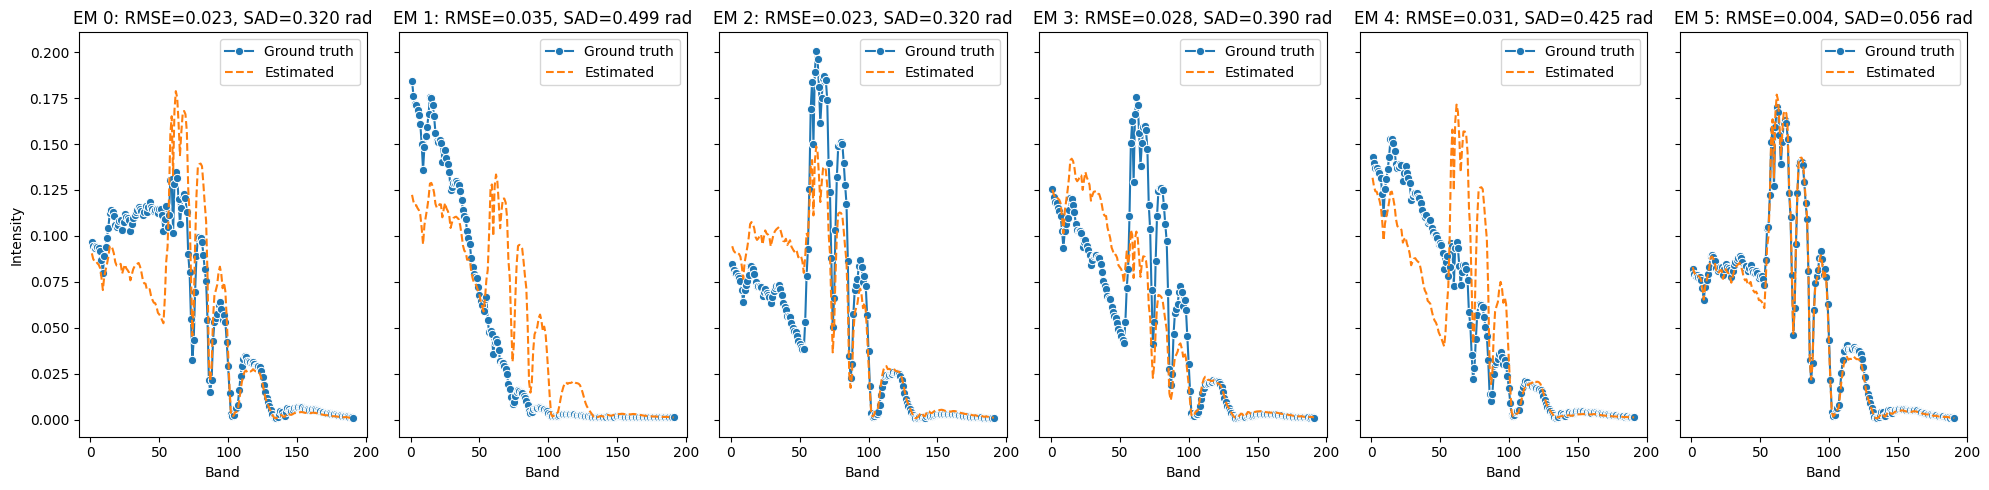

In [32]:
def spectral_angle(a, b):
    """SAD in radians between two 1D NumPy arrays."""
    cos_val = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
    cos_val = np.clip(cos_val, -1, 1)
    return np.arccos(cos_val)

# 1) Fetch one batch
batch = next(iter(dataloader))
x_t = batch['patch'][0].cpu()    # [bands, H, W]
abund_tensor = (model(batch['patch'].cuda(),
                       batch['vca'].cuda(),
                       batch['gt'].cuda(),return_full=True)
                .detach()
                .cpu()[0])      # [E, h', w']
spec_gt = batch['gt'][0].cpu()    # [E, bands]

# 2) Convert to NumPy
x_np = x_t.numpy()                       # [bands, H, W]
abund_np = abund_tensor.numpy()          # [E, h', w']
gt_np = spec_gt.numpy()                  # [E, bands]

bands, H, W = x_np.shape
E = 6

# 3) Reconstruct spectra via median on high-abundance pixels
lower_thresh = 0.10
upper_thresh = 1.0
rec_specs = []

for e in range(E):
    a_map = abund_tensor[e]  # tensor [h', w']
    mask = (a_map > lower_thresh) & (a_map < upper_thresh)
    if mask.sum() == 0:
        rec_specs.append(np.zeros(bands))
        continue
    # select pixel spectra: shape [bands, N_pixels]
    selected = x_t[:, mask.numpy()]
    # median along pixels
    med = selected.median(dim=1).values.numpy()
    rec_specs.append(med)

rec_specs = np.stack(rec_specs, axis=0)  # [E, bands]

# 4) Undo L2-normalization by scaling with ground-truth norms
# compute GT endmember L2 norms

norms_gt = np.linalg.norm(gt_np, axis=1)  # (E,)
rec_specs_unnorm = rec_specs * norms_gt[:, None]  # [E, bands]
# perm = [3, 1, 2, 0]
# rec_specs_unnorm = rec_specs_unnorm[perm]
# 5) Plot GT vs. Reconstructed (unnormalized) with metrics
cols = 6
rows = int(np.ceil(E / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 5), sharex=True, sharey=True)
axes = axes.flatten()
x_axis = np.arange(1, bands + 1)

for i in range(E):
    ax = axes[i]
    sns.lineplot(x=x_axis, y=gt_np[i], ax=ax, label='Ground truth', marker='o')
    sns.lineplot(x=x_axis, y=rec_specs_unnorm[i], ax=ax, label='Estimated', linestyle='--')
    rmse = np.sqrt(mean_squared_error(gt_np[i], rec_specs_unnorm[i]))
    sad = spectral_angle(gt_np[i], rec_specs_unnorm[i])
    ax.set_title(f'EM {i}: RMSE={rmse:.3f}, SAD={sad:.3f} rad')
    ax.set_xlabel('Band')
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(False)

# remove unused axes
for j in range(E, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [33]:
np.save('ViT_Endmembers_dc.npy', rec_specs_unnorm)